# Laboratorio 4 (Parte 2) — Inciso 3: Selección y construcción de variables predictoras

Se define el conjunto de variables predictoras a partir de las bandas e índices que sobrevivieron al análisis de fuga de información del inciso 2, se explica qué representa cada una y por qué podría contribuir a identificar cianobacteria, y se agrega una variable derivada (`verde_azul_ratio`). A partir de este inciso los notebooks trabajan sobre `dataset_ml_muestra.parquet` (la muestra de trabajo del inciso 1), el conjunto que usarán también los incisos de modelado (4 en adelante).

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

from src.config import RUTA_DATA_PROCESSED, RUTA_FIGURAS
from src.modelado import EXCLUIDAS, PREDICTORES, agregar_features, construir_respuesta

muestra = pd.read_parquet(RUTA_DATA_PROCESSED / "dataset_ml_muestra.parquet")
muestra = construir_respuesta(agregar_features(muestra))
print(f"{len(muestra):,} observaciones en la muestra de trabajo")
muestra[PREDICTORES + ["alta_cianobacteria"]].head()

299,992 observaciones en la muestra de trabajo


,verde,azul,b07,b08,b8a,b11,b12,fai,ndvi,ndwi,verde_azul_ratio,alta_cianobacteria
0,0.0527,0.0709,0.0236,0.0188,0.0166,0.0057,0.0041,0.001096,-0.244980,0.474126,0.743300,0
1,0.0545,0.0715,0.0211,0.0169,0.0153,0.0047,0.0033,-0.000268,-0.280851,0.526611,0.762238,0
2,0.0439,0.0631,0.0250,0.0219,0.0217,0.0086,0.0043,0.002726,-0.026667,0.334347,0.695721,0
3,0.0496,0.0691,0.0234,0.0192,0.0193,0.0068,0.0051,-0.000205,-0.216327,0.441860,0.717800,0
4,0.0523,0.0687,0.0219,0.0170,0.0170,0.0057,0.0029,0.000390,-0.244444,0.509380,0.761281,0


## 3.1 y 3.2 Conjunto de variables predictoras

`PREDICTORES` (`src/modelado.py`) reúne las variables que no participan en la construcción de la variable respuesta (inciso 2.5): 9 bandas/índices originales del inciso 1 más `verde_azul_ratio`, agregada en este inciso.

In [2]:
descripcion_predictoras = pd.DataFrame([
    {"variable": "verde", "tipo": "banda espectral (B03, 560 nm)",
     "descripcion": "Reflectancia en la región verde-amarilla.",
     "justificacion": "El pico de reflectancia verde es característico de la absorción de ficocianina y clorofila-a en cianobacterias; base de los algoritmos clásicos de color oceánico."},
    {"variable": "azul", "tipo": "banda espectral (B02, 490 nm)",
     "descripcion": "Reflectancia en la región azul.",
     "justificacion": "Junto con verde forma la base de las razones de color oceánico (OC2/OC3) para estimar clorofila en agua abierta; disminuye con mayor concentración de pigmentos."},
    {"variable": "b07", "tipo": "banda espectral (Red Edge 3, 783 nm)",
     "descripcion": "Reflectancia en el filo rojo (red edge).",
     "justificacion": "Zona de transición entre absorción de clorofila y dispersión celular; participa en la detección de biomasa algal y en el cálculo del FAI."},
    {"variable": "b08", "tipo": "banda espectral (NIR, 842 nm)",
     "descripcion": "Reflectancia en el infrarrojo cercano.",
     "justificacion": "La dispersión por partículas y biomasa suspendida eleva la reflectancia NIR; acumulaciones densas de fitoplancton o espuma superficial se distinguen del agua limpia."},
    {"variable": "b8a", "tipo": "banda espectral (NIR angosta, 865 nm)",
     "descripcion": "Reflectancia en el infrarrojo cercano, banda angosta.",
     "justificacion": "Insumo directo del Floating Algae Index (FAI); sensible a materia orgánica flotante en la superficie del agua."},
    {"variable": "b11", "tipo": "banda espectral (SWIR1, 1610 nm)",
     "descripcion": "Reflectancia en el infrarrojo de onda corta 1.",
     "justificacion": "Sensible al contenido de humedad y turbidez; ayuda a diferenciar agua limpia de agua con alta carga orgánica o sedimentaria."},
    {"variable": "b12", "tipo": "banda espectral (SWIR2, 2190 nm)",
     "descripcion": "Reflectancia en el infrarrojo de onda corta 2.",
     "justificacion": "Sensibilidad complementaria a b11 frente a turbidez y materiales flotantes."},
    {"variable": "fai", "tipo": "índice espectral derivado",
     "descripcion": "Floating Algae Index: desviación de b8a respecto a la línea base entre b07 y el rojo.",
     "justificacion": "Diseñado para detectar acumulaciones de materia flotante, incluidas floraciones superficiales de cianobacteria."},
    {"variable": "ndvi", "tipo": "índice espectral derivado",
     "descripcion": "Normalized Difference Vegetation Index (NIR vs. rojo).",
     "justificacion": "En agua abierta toma valores negativos; su magnitud es sensible a biomasa flotante y algas superficiales densas."},
    {"variable": "ndwi", "tipo": "índice espectral derivado",
     "descripcion": "Normalized Difference Water Index (verde vs. NIR).",
     "justificacion": "Delimita el cuerpo de agua; su magnitud covaría de forma inversa con la turbidez y la carga de biomasa."},
    {"variable": "verde_azul_ratio", "tipo": "característica derivada (inciso 3.3)",
     "descripcion": "Razón verde / azul.",
     "justificacion": "Análoga simplificada a las razones OC2/OC3 de color oceánico (O'Reilly et al., 1998) para estimar pigmentos fotosintéticos; no comparte bandas con la variable respuesta."},
])
descripcion_predictoras.to_csv(RUTA_DATA_PROCESSED / "p2_descripcion_predictoras.csv", index=False)
descripcion_predictoras

,variable,tipo,descripcion,justificacion
0,verde,"banda espectral (B03, 560 nm)",Reflectancia en la región verde-amarilla.,El pico de reflectancia verde es característic...
1,azul,"banda espectral (B02, 490 nm)",Reflectancia en la región azul.,Junto con verde forma la base de las razones d...
2,b07,"banda espectral (Red Edge 3, 783 nm)",Reflectancia en el filo rojo (red edge).,Zona de transición entre absorción de clorofil...
3,b08,"banda espectral (NIR, 842 nm)",Reflectancia en el infrarrojo cercano.,La dispersión por partículas y biomasa suspend...
4,b8a,"banda espectral (NIR angosta, 865 nm)","Reflectancia en el infrarrojo cercano, banda a...",Insumo directo del Floating Algae Index (FAI);...
5,b11,"banda espectral (SWIR1, 1610 nm)",Reflectancia en el infrarrojo de onda corta 1.,Sensible al contenido de humedad y turbidez; a...
6,b12,"banda espectral (SWIR2, 2190 nm)",Reflectancia en el infrarrojo de onda corta 2.,Sensibilidad complementaria a b11 frente a tur...
7,fai,índice espectral derivado,Floating Algae Index: desviación de b8a respec...,Diseñado para detectar acumulaciones de materi...
8,ndvi,índice espectral derivado,Normalized Difference Vegetation Index (NIR vs...,En agua abierta toma valores negativos; su mag...
9,ndwi,índice espectral derivado,Normalized Difference Water Index (verde vs. N...,Delimita el cuerpo de agua; su magnitud covarí...


## 3.3 Ingeniería de características

Se agrega una única variable derivada, `verde_azul_ratio` (`src/modelado.agregar_features`), la razón entre las bandas verde y azul. Es análoga simplificada a las razones de color oceánico OC2/OC3 (O'Reilly et al., 1998, *Ocean color chlorophyll algorithms for SeaWiFS*), diseñadas para estimar la concentración de pigmentos fotosintéticos a partir de reflectancias visibles, y no comparte bandas con `ndci`/`clorofila`, por lo que no introduce fuga de información.

Se consideraron y descartaron razones adicionales entre b11, b12, b07 y b8a (por ejemplo `b11/b12` como proxy de turbidez, o una pendiente del red edge con b07/b8a): esas cuatro bandas ya entran individualmente como predictoras, y una razón entre ellas sería casi colineal con las bandas que la componen sin aportar señal independiente, por lo que se prefiere mantener el conjunto de predictoras simple.

## Correlación de cada predictora con la variable respuesta

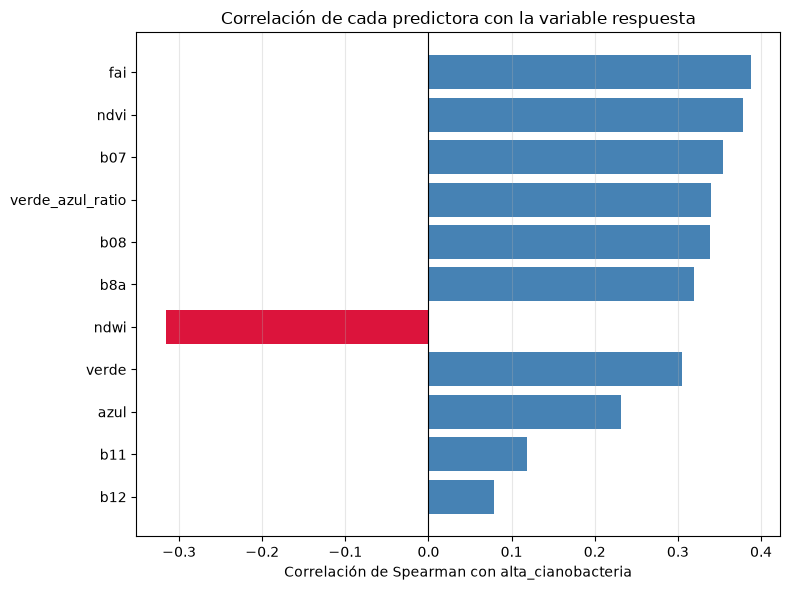

In [3]:
correlaciones = {}
for var in PREDICTORES:
    rho, _ = spearmanr(muestra[var], muestra["alta_cianobacteria"])
    correlaciones[var] = rho
correlaciones = pd.Series(correlaciones).sort_values(key=np.abs, ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colores_barra = ["crimson" if v < 0 else "steelblue" for v in correlaciones]
ax.barh(correlaciones.index, correlaciones.values, color=colores_barra)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Correlación de Spearman con alta_cianobacteria")
ax.set_title("Correlación de cada predictora con la variable respuesta")
ax.grid(alpha=0.3, axis="x")
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "p2_correlacion_predictoras_respuesta.png", dpi=150)
plt.show()

`ndvi` y `verde_azul_ratio` muestran la correlación positiva más fuerte con `alta_cianobacteria`, consistente con que ambas capturan, de forma indirecta, la señal de pigmentos fotosintéticos que también produce el NDCI. `ndwi` muestra la correlación negativa más fuerte, coherente con que las floraciones dispersan y reflejan más luz en el visible/NIR, reduciendo la señal de "agua limpia" que captura ese índice. Las bandas SWIR (`b11`, `b12`) muestran correlaciones más débiles, aportando información complementaria más que señal dominante.

### Self-check

In [4]:
assert set(PREDICTORES).isdisjoint(EXCLUIDAS), "una predictora está marcada también como excluida"
assert muestra[PREDICTORES].isna().sum().sum() == 0, "hay predictoras con valores faltantes en la muestra"
assert np.isfinite(muestra["verde_azul_ratio"]).all(), "verde_azul_ratio tiene valores no finitos"
print("OK: conjunto de predictoras consistente y sin valores faltantes en la muestra de trabajo.")

OK: conjunto de predictoras consistente y sin valores faltantes en la muestra de trabajo.
